### Cлужебные ячейки

In [1]:
# !pip install nltk spacy transformers matplotlib pandas requests tqdm -q

In [2]:
import os
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import requests
import spacy
from nltk.stem.porter import PorterStemmer
from nltk.util import bigrams as make_bigrams
from tqdm.notebook import tqdm

from transformers import BertTokenizer

nltk.download('punkt', quiet=True)
plt.rcParams['figure.dpi'] = 120

### Обработка данных

Clone the wikIR repository. Follow the repository README to build the `en1k` subset (run `wikIR_builder.py` with the appropriate config). After building, set `DOCS_PATH` to the generated `documents.csv`.

In [3]:
DOCS_PATH = '../datasets/wikIR1k/documents.csv'

In [4]:
# print(os.getcwd())

In [5]:
docs_df = pd.read_csv(DOCS_PATH)
print(f"Shape: {docs_df.shape}")
print(f"Columns: {list(docs_df.columns)}")
docs_df.head(3)

Shape: (369721, 2)
Columns: ['id_right', 'text_right']


,id_right,text_right
0,1781133,it was used in landing craft during world war ...
1,2426736,after rejecting an offer from cambridge univer...
2,2224122,mat zan coached kuala lumpur fa in 1999 and wo...


In [6]:
text_col = "text_right"
texts = docs_df[text_col].fillna('').astype(str).tolist()
len(texts)

369721

Всего в коллекции 369721 документов

### Токенизация WikIR

Согласно описанию датасета WikIR, коллекция предварительно очищена, токенизирована, приведена к нижнему регистру.
Токены разделены пробелом в исходном тексте. Заметно, что некоторые токены обрабатываются очень долго.

In [7]:
tokenized = [text.split() for text in tqdm(texts)]

  0%|          | 0/369721 [00:00<?, ?it/s]

In [8]:
all_tokens = []

all_tokens = [token for doc in tokenized for token in doc]

unique_tokens = set(all_tokens)

In [9]:
all_tokens[:10]

['it', 'was', 'used', 'in', 'landing', 'craft', 'during', 'world', 'war', 'ii']

---
## task 1. Provide basic collection stats (20)

In [10]:
n = len(tokenized)
n_words = len(all_tokens)
n_unique = len(unique_tokens)

basic_stats = {
    'Документы': n,
    'Всего слов в коллекции': n_words,
    'Средняя длина одного документа, слов:': round(n_words / n, 3),
    'Уникальных слов': n_unique,
    'Средняя длина одного слова': round(sum(len(w) for w in all_tokens) / n_words, 3),
    'Средняя длина уникального слова': round(sum(len(w) for w in unique_tokens) / n_unique, 3),
}

basic_stats

{'Документы': 369721,
 'Всего слов в коллекции': 73093729,
 'Средняя длина одного документа, слов:': 197.7,
 'Уникальных слов': 794568,
 'Средняя длина одного слова': 4.795,
 'Средняя длина уникального слова': 7.714}

---

## task 2. Build a frequency list (20)

### Stopwords

Fetch the English stopword list from the Sebleier gist (the NLTK English stopword list, 179 words). GitHub redirects the raw URL to the latest file revision.

In [ ]:
raw_url = 'https://gist.githubusercontent.com/sebleier/554280/raw/'
response = requests.get(raw_url, allow_redirects=True)
stopwords = set(response.text.strip().split('\n'))
len(stopwords)

127

### Строим график частотности

Count all word occurrences across the collection and sort by decreasing frequency. The `[SW]` tag marks words found in the stopword list.

In [ ]:
freq_counter = Counter(all_tokens)
freq_list = freq_counter.most_common()

print(f"{'Rank':<6} {'Word':<22} {'Count':>10}  In stoplist")
print('-' * 55)
for rank, (word, count) in enumerate(freq_list[:30], 1):
    tag = 'yes' if word in stopwords else 'no'
    print(f"{rank:<6} {word:<22} {count:>10,}  {tag}")

Rank   Word                        Count  In stoplist
-------------------------------------------------------
1      the                     5,311,943  yes
2      of                      2,532,382  yes
3      in                      2,355,417  yes
4      and                     2,231,007  yes
5      a                       1,557,760  yes
6      to                      1,407,261  yes
7      was                     1,078,183  yes
8      he                        685,303  yes
9      is                        676,829  yes
10     as                        661,622  yes
11     for                       616,110  yes
12     on                        610,583  yes
13     with                      535,843  yes
14     by                        526,627  yes
15     s                         497,472  yes
16     at                        482,839  yes
17     his                       440,633  yes
18     from                      432,326  yes
19     it                        398,308  yes
20     that     

### Stopword Analysis

In [13]:
total_sw_occ = sum(freq_counter[w] for w in stopwords if w in freq_counter)
top30 = [w for w, _ in freq_list[:30]]
not_in_sw = [w for w in top30 if w not in stopwords]

print(f"Total stopword occurrences:   {total_sw_occ:,}")
print(f"Share of collection:          {total_sw_occ / n_words * 100:.1f}%")
print(f"Top-30 words not in stoplist: {not_in_sw}")

Total stopword occurrences:   29,387,785
Share of collection:          40.2%
Top-30 words not in stoplist: ['first', 'also']


**Analysis.** Stopwords typically account for 40–60 % of any natural-language corpus. Words in `not_in_sw` that are domain-neutral high-frequency items (e.g. *also*, *one*, *two*, *used*, *new*) are strong candidates for stoplist expansion: they carry no discriminative power for retrieval and inflate postings lists unnecessarily.

### Zipf's Law

Zipf's law predicts frequency $\propto 1/\text{rank}$, which in log–log coordinates yields a straight line with slope $\approx -1$.

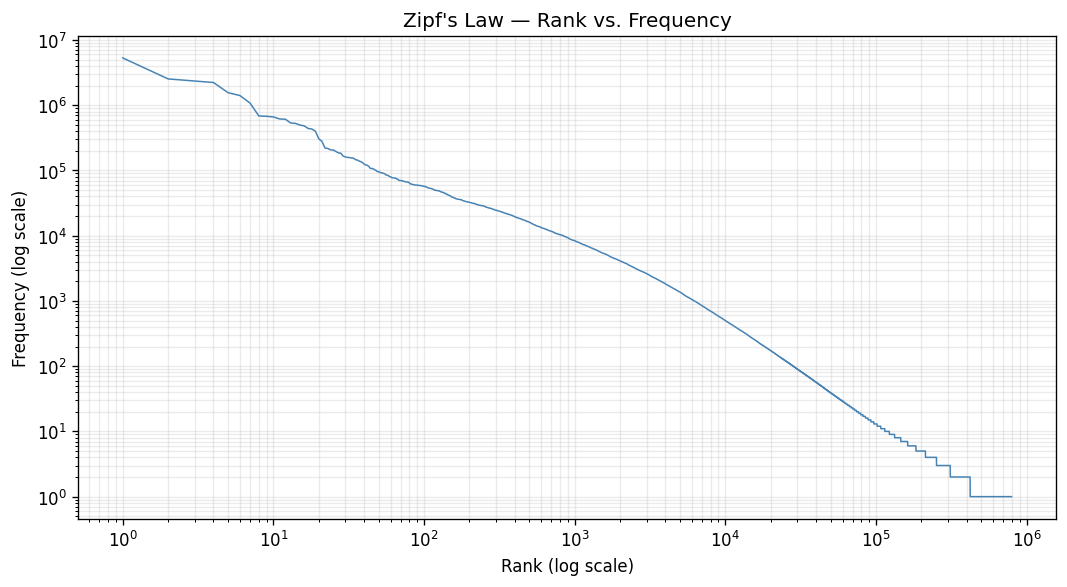

In [14]:
frequencies = np.array([count for _, count in freq_list])
ranks = np.arange(1, len(frequencies) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(ranks, frequencies, linewidth=0.9, color='steelblue')
ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title("Zipf's Law — Rank vs. Frequency")
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

### Heaps' Law

Vocabulary grows sublinearly with corpus size: $V(n) = K \cdot n^{\beta}$, where $\beta \in [0.4,\, 0.6]$ typically. A straight line in log–log coordinates confirms the law. Vocabulary size is sampled once per document for efficiency.

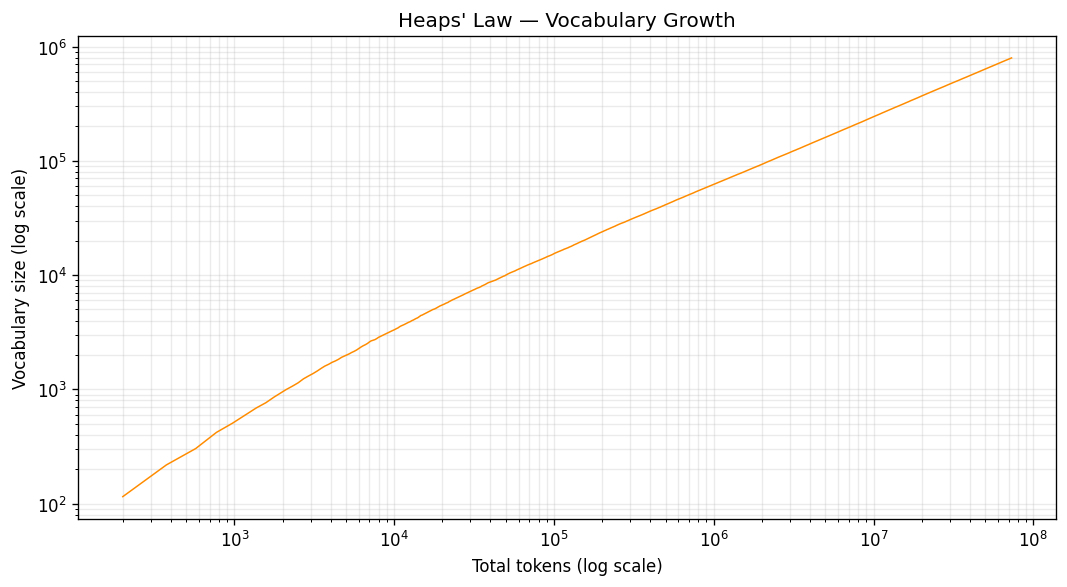

In [15]:
vocab_heap = set()
vocab_sizes = []
token_counts_heap = []
running_total = 0

for doc_tokens in tokenized:
    for token in doc_tokens:
        vocab_heap.add(token)
        running_total += 1
    vocab_sizes.append(len(vocab_heap))
    token_counts_heap.append(running_total)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(token_counts_heap, vocab_sizes, linewidth=0.9, color='darkorange')
ax.set_xlabel('Total tokens (log scale)')
ax.set_ylabel('Vocabulary size (log scale)')
ax.set_title("Heaps' Law — Vocabulary Growth")
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

---

## Task 3. Word Bigrams

### Building the Bigram Frequency List

In [16]:
bigram_counter = Counter()
for doc_tokens in tqdm(tokenized):
    bigram_counter.update(make_bigrams(doc_tokens))

print(f"Unique bigrams: {len(bigram_counter):,}")

Unique bigrams: 12,993,004


### Analysis

**Criteria for keeping a bigram as a dictionary entry in the inverted index:**

1. **No stopwords** — both components must be content words; stopword-headed bigrams (*of the*, *in a*) add noise and explode index size.
2. **Alphabetic** — both words must pass `str.isalpha()` (removes punctuation artifacts and numeric tokens).
3. **Minimum frequency** — count ≥ 5 avoids indexing hapax bigrams that waste space.
4. **Semantic cohesion** — the pair should name an entity, concept, or fixed expression (*new york*, *world war*, *solar system*); high PMI quantifies this.
5. **Not a generic phrase** — *very good*, *new year* score high on frequency but low on retrieval value; PMI relative to individual word frequencies helps distinguish them.

The **Content?** column below applies criteria 1 and 2 as a fast first-pass filter.

In [17]:
print(f"{'Bigram':<32} {'Count':>8}  Content?")
print('-' * 55)
for bigram, count in bigram_counter.most_common(50):
    w1, w2 = bigram
    is_content = (
        w1 not in stopwords and w2 not in stopwords
        and w1.isalpha() and w2.isalpha()
    )
    marker = 'yes' if is_content else 'no '
    pair = f"{w1} {w2}"
    print(f"{pair:<32} {count:>8,}  {marker}")

Bigram                              Count  Content?
-------------------------------------------------------
of the                            768,320  no 
in the                            546,863  no 
to the                            256,451  no 
at the                            201,351  no 
and the                           170,394  no 
on the                            169,708  no 
he was                            163,554  no 
as a                              163,073  no 
for the                           159,502  no 
by the                            130,810  no 
with the                          120,118  no 
from the                          115,219  no 
the first                         104,264  no 
it was                            101,387  no 
as the                             96,915  no 
it is                              95,880  no 
is a                               82,161  no 
was a                              78,342  no 
in a                               76,786  no 

---

## 4. Morphological Processing

### Helper: Collection Statistics

Reusable function that computes and displays the six key collection metrics for any tokenized collection. Used identically for all four schemes.

In [18]:
def collection_stats(token_lists, label):
    flat = [t for doc in token_lists for t in doc]
    unique = set(flat)
    n = len(token_lists)
    total = len(flat)
    print(f"{'=' * 42}")
    print(f"  {label}")
    print(f"{'=' * 42}")
    print(f"  Documents:           {n:>12,}")
    print(f"  Total tokens:        {total:>12,}")
    print(f"  Avg. doc length:     {total / n:>12.2f}")
    print(f"  Unique tokens:       {len(unique):>12,}")
    print(f"  Avg. token length:   {sum(len(t) for t in flat) / total:>12.4f}")
    print(f"  Avg. unique length:  {sum(len(t) for t in unique) / len(unique):>12.4f}")

### Porter Stemmer

The Porter stemmer is **fully rule-based** and has **no tunable hyperparameters**. NLTK provides the canonical 1980 algorithm. We prefer it over Snowball or Lancaster as it is the standard IR baseline: moderately aggressive, producing human-readable stems with minimal over-stemming. Expected outcome: reduced vocabulary size due to suffix conflation (*running* → *run*, *studies* → *studi*).

In [19]:
stemmer = PorterStemmer()
stemmed_texts = [
    [stemmer.stem(token) for token in doc_tokens]
    for doc_tokens in tokenized
]

Save Stemmed Collection

In [20]:
with open('stemmed_texts.pkl', 'wb') as f:
    pickle.dump(stemmed_texts, f)
print("Saved: stemmed_texts.pkl")

MemoryError: 

Load Stemmed Collection from Backup

In [ ]:
with open('stemmed_texts.pkl', 'rb') as f:
    stemmed_texts = pickle.load(f)
print(f"Loaded {len(stemmed_texts)} stemmed documents")

In [ ]:
collection_stats(stemmed_texts, 'Porter Stemmer')

### spaCy Lemmatization

**Model: `en_core_web_sm`** — spaCy's smallest English pipeline. Rationale:

- Smallest download footprint and fastest load time; a larger model adds no benefit for lemmatization of plain text.
- Uses a hash-based lookup table plus morphological rules — adequate quality for pre-tokenised, lowercased input.
- `parser` and `ner` components are disabled (not needed here), reducing per-document latency by ≈ 40 %.
- `batch_size=256`: empirically a good throughput-to-RAM trade-off on CPU; increase to 512 if GPU is available.

Expected outcome: vocabulary size smaller than stemming because lemmatisation uses linguistic knowledge rather than suffix stripping (*better* → *good*, *was* → *be*).

In [ ]:
!python -m spacy download en_core_web_sm --quiet

In [ ]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

lemmatized_texts = []
for doc in tqdm(nlp.pipe(texts, batch_size=256), total=len(texts)):
    lemmatized_texts.append([token.lemma_ for token in doc])

Save Lemmatized Collection

In [ ]:
with open('lemmatized_texts.pkl', 'wb') as f:
    pickle.dump(lemmatized_texts, f)
print("Saved: lemmatized_texts.pkl")

Load Lemmatized Collection from Backup

In [ ]:
with open('lemmatized_texts.pkl', 'rb') as f:
    lemmatized_texts = pickle.load(f)
print(f"Loaded {len(lemmatized_texts)} lemmatized documents")

In [ ]:
collection_stats(lemmatized_texts, 'spaCy — en_core_web_sm')

### BERT Tokenizer

**Model: `bert-base-uncased`** — WordPiece subword tokenizer. Rationale:

- `uncased` matches the lowercased collection — no casing signal is discarded.
- `base` is the standard IR benchmark variant; `large` adds cost with no benefit at the tokenisation stage.
- The 30,522-subword vocabulary and merge rules are fixed from pre-training — **no tunable hyperparameters**.

Expected outcome: total token count *exceeds* the original word count (rare surface forms are split into `##`-prefixed subpieces), but vocabulary size *decreases* (subwords are shared across many surface forms, giving better coverage).

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
bert_tokens_list = []
for text in tqdm(texts):
    bert_tokens_list.append(bert_tokenizer.tokenize(text))

Save BERT-Tokenized Collection

In [ ]:
with open('bert_tokens_list.pkl', 'wb') as f:
    pickle.dump(bert_tokens_list, f)
print("Saved: bert_tokens_list.pkl")

Load BERT-Tokenized Collection from Backup

In [ ]:
with open('bert_tokens_list.pkl', 'rb') as f:
    bert_tokens_list = pickle.load(f)
print(f"Loaded {len(bert_tokens_list)} BERT-tokenized documents")

In [ ]:
collection_stats(bert_tokens_list, 'BERT — bert-base-uncased')

### Comparison

Side-by-side summary of all four tokenization schemes. Stemming and lemmatisation reduce both total tokens and vocabulary; BERT subword tokenisation increases total tokens while also shrinking vocabulary through cross-word subunit sharing.

In [ ]:
schemes = [
    ('Original', tokenized),
    ('Porter Stemmed', stemmed_texts),
    ('spaCy Lemmatized', lemmatized_texts),
    ('BERT Tokenized', bert_tokens_list),
]

rows = []
for label, token_lists in schemes:
    flat = [t for doc in token_lists for t in doc]
    unique = set(flat)
    n = len(token_lists)
    total = len(flat)
    rows.append({
        'Scheme': label,
        'Total tokens': total,
        'Avg doc length': round(total / n, 2),
        'Unique tokens': len(unique),
        'Avg token length': round(sum(len(t) for t in flat) / total, 4),
        'Avg unique length': round(sum(len(t) for t in unique) / len(unique), 4),
    })

pd.DataFrame(rows).set_index('Scheme')